<a href="https://colab.research.google.com/github/Shrakky2k23/Shrakky2k23/blob/main/Amazon_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("amazon.csv")

In [30]:
print(df.head())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

In [31]:
print(df.shape)

(1465, 16)


In [32]:
print(df.columns)

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [34]:
print(df.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [35]:
df.dropna(inplace=True)

In [36]:
print(df.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [37]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1463 non-null   object
 1   product_name         1463 non-null   object
 2   category             1463 non-null   object
 3   discounted_price     1463 non-null   object
 4   actual_price         1463 non-null   object
 5   discount_percentage  1463 non-null   object
 6   rating               1463 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1463 non-null   object
 9   user_id              1463 non-null   object
 10  user_name            1463 non-null   object
 11  review_id            1463 non-null   object
 12  review_title         1463 non-null   object
 13  review_content       1463 non-null   object
 14  img_link             1463 non-null   object
 15  product_link         1463 non-null   object
dtypes: object(1

In [39]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '')
df['discounted_price'] = df['discounted_price'].str.replace(',', '')
df['discounted_price'] = df['discounted_price'].astype(float)

In [40]:
df['actual_price'] = df['actual_price'].str.replace('₹', '')
df['actual_price'] = df['actual_price'].str.replace(',', '')
df['actual_price'] = df['actual_price'].astype(float)

In [41]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [42]:
print(df.describe())

       discounted_price   actual_price       rating
count       1463.000000    1463.000000  1462.000000
mean        3129.277122    5451.068544     4.096717
std         6948.222850   10881.018448     0.289497
min           39.000000      39.000000     2.000000
25%          325.000000     800.000000     4.000000
50%          799.000000    1690.000000     4.100000
75%         1999.000000    4312.500000     4.300000
max        77990.000000  139900.000000     5.000000


In [43]:
print(df['category'].value_counts().head(10))

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        231
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                      68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                             63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              52
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  27
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice                            24
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Home&Kitch

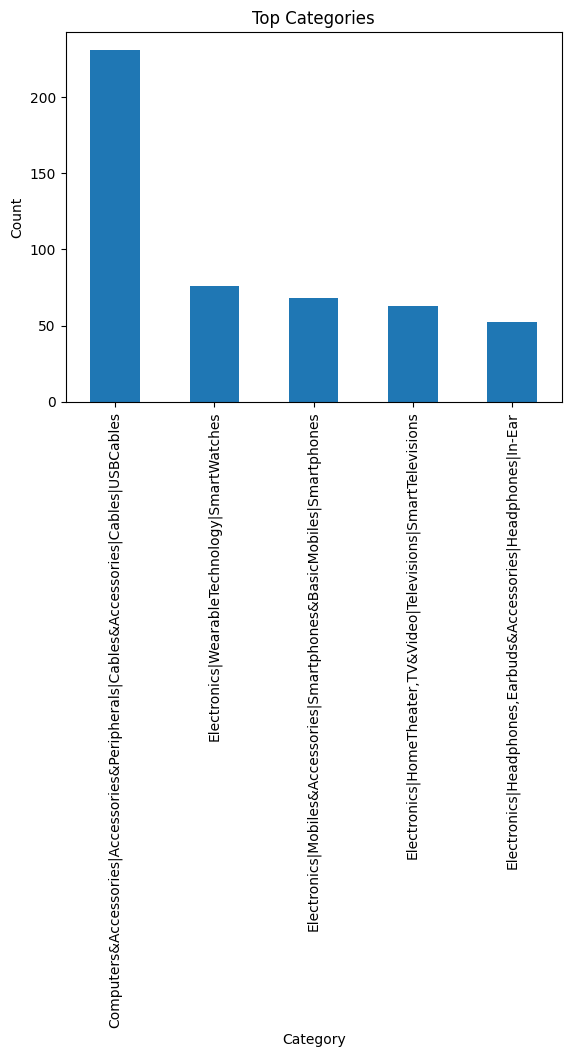

In [44]:
top_categories = df['category'].value_counts().head(5)

top_categories.plot(kind='bar')

plt.title("Top Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [45]:
top_rated = df.sort_values(by='rating', ascending=False)

print(top_rated[['product_name', 'rating']].head(10))

                                           product_name  rating
775   Amazon Basics Wireless Mouse | 2.4 GHz Connect...     5.0
174   Syncwire LTG to USB Cable for Fast Charging Co...     5.0
1145  Swiffer Instant Electric Water Heater Faucet T...     4.8
1201  Oratech Coffee Frother electric, milk frother ...     4.8
1299  Instant Pot Air Fryer, Vortex 2QT, Touch Contr...     4.8
1226  Zuvexa USB Rechargeable Electric Foam Maker - ...     4.7
1275  Multifunctional 2 in 1 Electric Egg Boiling St...     4.7
459   Spigen EZ Fit Tempered Glass Screen Protector ...     4.7
1223  FIGMENT Handheld Milk Frother Rechargeable, 3-...     4.7
249   Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...     4.7


In [46]:
expensive = df.sort_values(by='actual_price', ascending=False)

print(expensive[['product_name', 'actual_price']].head(10))

                                           product_name  actual_price
249   Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...      139900.0
255   VU 164 cm (65 inches) The GloLED Series 4K Sma...       85000.0
283   LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...       79990.0
1354  LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...       75990.0
568   Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...       74999.0
192   Samsung 138 cm (55 inches) Crystal 4K Neo Seri...       70900.0
332   MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...       69999.0
325   OnePlus 163.8 cm (65 inches) U Series 4K LED S...       69999.0
276   Samsung 138 cm (55 inches) Crystal 4K Series U...       69900.0
150   VU 138 cm (55 inches) Premium Series 4K Ultra ...       65000.0


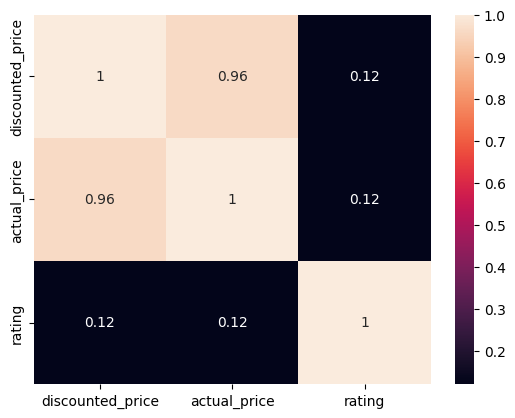

In [47]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

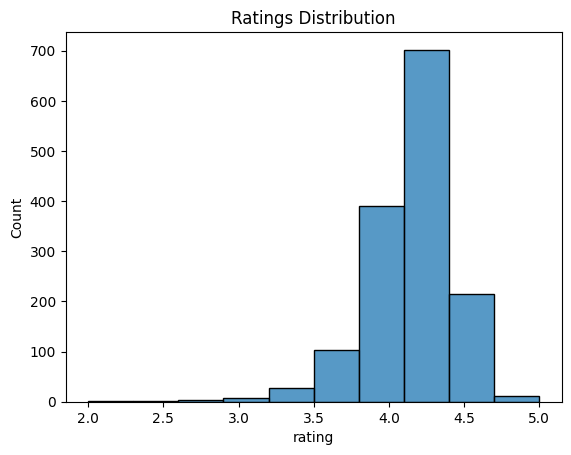

In [48]:
sns.histplot(df['rating'], bins=10)

plt.title("Ratings Distribution")

plt.show()